In [1]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:

holdings = pd.read_csv("https://www.ishares.com/us/products/239723/ishares-s-p-100-etf/latest-holdings.csv", skiprows=9)  
equity_holdings = holdings[holdings["Asset Class"] == "Equity"].copy()
print(equity_holdings.head())

  Ticker              Name                  Sector Asset Class  \
0   NVDA            NVIDIA  Information Technology      Equity   
1   AAPL             APPLE  Information Technology      Equity   
2   MSFT         MICROSOFT  Information Technology      Equity   
3   AMZN    AMAZON.COM INC  Consumer Discretionary      Equity   
4  GOOGL  ALPHABET CLASS A           Communication      Equity   

       Market Value  Weight (%)    Notional Value       Quantity   Price  \
0  2,236,429,581.68       11.09  2,236,429,581.68  10,241,938.00  218.36   
1  2,028,236,136.68       10.06  2,028,236,136.68   6,210,724.00  326.57   
2  1,546,853,512.88        7.67  1,546,853,512.88   3,141,202.00  492.44   
3  1,042,668,931.98        5.17  1,042,668,931.98   4,139,382.00  251.89   
4    824,709,638.40        4.09    824,709,638.40   2,479,584.00  332.60   

        Location Exchange Currency  FX Rate Market Currency Accrual Date  
0  United States   NASDAQ      USD      1.0             USD            

In [3]:
equity_holdings["Ticker"].replace({"BRK B":"BRK-B"})
equity_holdings["Ticker"] = equity_holdings["Ticker"].replace({"BRK B": "BRK-B"})
equity_holdings[equity_holdings["Ticker"] == "BRK-B"]

,Ticker,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Quantity,Price,Location,Exchange,Currency,FX Rate,Market Currency,Accrual Date
11,BRK-B,BERKSHIRE HATHAWAY INC CLASS B,Financials,Equity,"393,164,304.00",1.95,"393,164,304.00","775,472.00",507.00,United States,NYSE,USD,1.0,USD,-


In [4]:
members = pd.DataFrame({
    "ticker":        equity_holdings["Ticker"],
    "snapshot_date": "2026-08-31",
    "source":        "https://www.ishares.com/us/products/239723/ishares-s-p-100-etf/latest-holdings.csv",
})



In [5]:
members.to_csv("../data/reference/sp100_members.csv", index=False)

In [6]:
tickers = pd.read_csv("../data/reference/sp100_members.csv")["ticker"].tolist() #get tickers for each constituent

import yfinance as yfinance 

tickers_data = yfinance.download(tickers, start="2018-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]
benchmark_data = yfinance.download(["SMH", "VXUS", "TLT", "GLD", "MAGS"], start="2018-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]
spy_data = yfinance.download(["SPY"], start="2013-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]

tickers_data.head()

[*********************100%***********************]  101 of 101 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.232384,68.287086,50.148407,133.947632,177.699997,48.262585,10.98,135.948105,112.758095,59.450500,...,NaN,191.993942,112.165863,86.965218,38.685268,107.688171,33.147881,48.100590,28.731451,57.811142
2018-01-03,40.225361,69.355728,50.259304,134.565796,181.039993,49.117916,11.55,138.513428,113.197517,60.209999,...,NaN,194.007965,112.793671,88.891991,39.064754,108.760277,32.466721,48.470650,28.982077,58.946579
2018-01-04,40.412209,68.960182,50.173996,136.159180,183.220001,49.399990,12.12,137.929718,111.543655,60.479500,...,NaN,194.850021,112.182388,89.468643,39.365463,109.164658,32.571980,49.076942,29.008307,59.028168
2018-01-05,40.872326,70.160629,50.319012,137.282394,185.339996,49.682064,11.88,138.751526,112.262756,61.457001,...,NaN,198.565598,113.611542,89.742859,39.608910,111.779022,32.497681,49.407635,29.180241,58.980564
2018-01-08,40.720516,69.036514,50.173996,138.379440,185.039993,50.883179,12.28,138.713089,113.461174,62.343498,...,NaN,195.119141,115.189339,90.832809,39.666191,112.230446,32.441944,48.848587,29.611551,59.245724


In [7]:
members_returns = np.log(tickers_data / tickers_data.shift(1)) #individual daily log normal returns of member constituent stocks
benchmark_returns = np.log(benchmark_data / benchmark_data.shift(1)).squeeze() #individual daily log returns of AI index proxy to calculate AI factor coefficient of each member constituent (Ticker = SMH, Seminconductor ETF 
spy_returns = np.log(spy_data / spy_data.shift(1)).squeeze() #benchmark/market returns to calcualte beta
      

In [8]:
quarter_ends = members_returns.index.to_series().groupby(members_returns.index.to_period("Q")).max() #create quarter-ends in a series , this is a list of dates in the index that represent quarter ends


In [9]:
def ols_regression(y: pd.Series, x: pd.Series, min_obs: int = 200):#   OLS of y on x. to be used for fitting  residuals of individual stock returns, AI-proxy returns (SMH), and market returns (SPY)
    df = pd.concat({"y": y, "x": x}, axis=1).dropna()
    if len(df) < min_obs:
        return None
    yv, xv = df["y"], df["x"]

    beta  = yv.cov(xv) / xv.var()
    alpha = yv.mean() - beta * xv.mean()
    resid = yv - alpha - beta * xv
    r2    = beta**2 * xv.var() / yv.var()

    return {"alpha": alpha, "beta": beta, "resid": resid, "n": len(df), "r2": r2}

In [10]:
pair = pd.concat({"y": members_returns["NVDA"], "x": spy_returns}, axis=1).dropna().tail(252)  # align, then window
fit  = ols_regression(pair["y"], pair["x"])   # sanity check: NVDA market beta over the last 252 joint days
print(fit["beta"] if fit else f"insufficient overlap: {len(pair)} obs")


1.9151908932588289


/var/folders/55/nnjtr0k13kb9t31swqzssvw80000gn/T/ipykernel_4618/1188859321.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pair = pd.concat({"y": members_returns["NVDA"], "x": spy_returns}, axis=1).dropna().tail(252)  # align, then window


In [11]:
MAG7    = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA"]
M7_FULL = MAG7 + ["GOOG"]   # carve-out = Mag-7 plus both Alphabet share classes


In [12]:
loadings_by_qe = {}
for qe in quarter_ends:  # loadings at each basket formation date, walk-forward (no foresight)
    pos = members_returns.index.get_loc(qe)   # integer position of this quarter-end
    if pos < 251:                             # need 252 return rows behind the formation date
        continue

    members_window = members_returns.iloc[pos-251 : pos+1]           # trailing 252 daily returns
    spy_window     = spy_returns.reindex(members_window.index)       # SPY aligned to the window's dates

    # regress SMH returns on SPY returns and keep the residual: SMH's return with the
    # market component removed. This series is the AI factor for this window.
    resid_smh = ols_regression(
        benchmark_returns["SMH"].reindex(members_window.index),
        spy_window)["resid"]

    # two regressions per stock: (1) returns on SPY returns -> market beta + residual;
    # (2) that residual on the SMH residual -> AI beta (lambda)
    rows = {}
    for ticker in members_window.columns:
        if ticker in M7_FULL:                 # Mag-7 carved out; analyzed as its own basket
            continue
        fit1 = ols_regression(members_window[ticker], spy_window)
        if fit1 is None: continue
        fit2 = ols_regression(fit1["resid"], resid_smh)
        if fit2 is None: continue
        rows[ticker] = {"beta_mkt": fit1["beta"],   # market beta
                        "ai_beta":  fit2["beta"],   # AI factor loading (lambda)
                        "n_obs":    fit1["n"]}      # observations used in the fit (<= 252)

    loadings_by_qe[qe] = pd.DataFrame.from_dict(rows, orient="index")

loadings = loadings_by_qe[max(loadings_by_qe)]      # latest formation's table, for the cross-section analysis
print(f"{len(loadings_by_qe)} formations,",
      f"first {min(loadings_by_qe).date()}, last {max(loadings_by_qe).date()}")

/var/folders/55/nnjtr0k13kb9t31swqzssvw80000gn/T/ipykernel_4618/471518767.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({"y": y, "x": x}, axis=1).dropna()


31 formations, first 2019-03-29, last 2026-09-11


In [13]:
loadings.sort_values("ai_beta", ascending=False).head(10) #stocks with the most beta to SMH/AI (λ)

,beta_mkt,ai_beta,n_obs
MU,3.329560,1.994347,252
INTC,2.804748,1.743344,252
LRCX,3.238109,1.539142,252
AMAT,2.722424,1.490408,252
AMD,3.083946,1.446284,252
GEV,2.019398,0.711710,252
TXN,1.461875,0.682523,252
AVGO,2.117519,0.678718,252
CAT,1.739081,0.643173,252
QCOM,2.044190,0.548448,252


In [14]:
loadings.sort_values("beta_mkt", ascending=False).head(10) #stocks with the most beta to SPY/market (β)

,beta_mkt,ai_beta,n_obs
MU,3.329560,1.994347,252
LRCX,3.238109,1.539142,252
AMD,3.083946,1.446284,252
INTC,2.804748,1.743344,252
AMAT,2.722424,1.490408,252
AVGO,2.117519,0.678718,252
QCOM,2.044190,0.548448,252
GEV,2.019398,0.711710,252
ORCL,2.018734,0.153788,252
PLTR,1.941687,-0.363315,252


In [15]:
momentum = (tickers_data.iloc[pos-21] / tickers_data.iloc[pos-252] - 1).drop(M7_FULL, errors="ignore") #momentum is defined as the stocks 12 month return (t-21 price / t-252 price) 
loadings["momentum"] = momentum #add momentum column for each stock to the loadings table
loadings.sort_values("momentum", ascending=False).head(10) #stocks with the most momentum

#only for sorting purposes, not a separate factor 


,beta_mkt,ai_beta,n_obs,momentum
MU,3.329560,1.994347,252,5.519661
INTC,2.804748,1.743344,252,3.075494
AMAT,2.722424,1.490408,252,2.369191
LRCX,3.238109,1.539142,252,2.054348
AMD,3.083946,1.446284,252,2.027015
CAT,1.739081,0.643173,252,1.041337
CSCO,1.023151,0.200320,252,0.855939
FDX,0.905734,-0.087926,252,0.820147
MRK,0.184921,-0.242735,252,0.634699
LLY,0.306672,-0.325502,252,0.624949


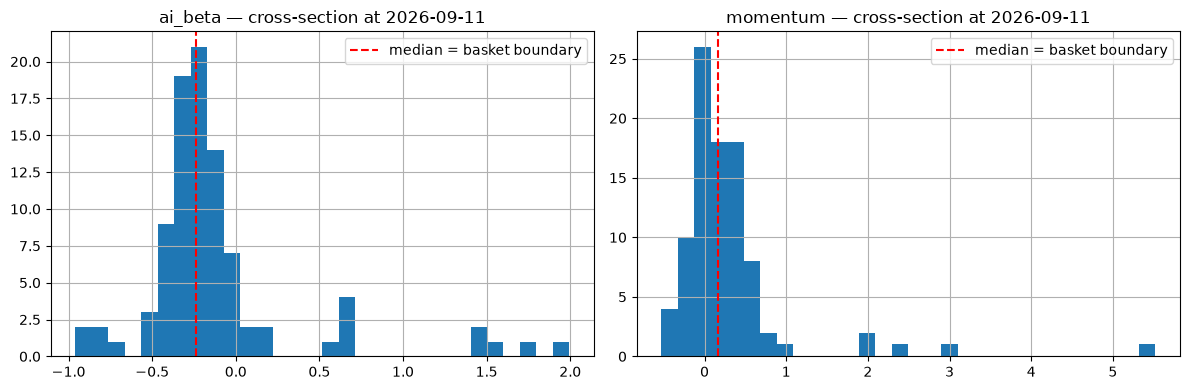

In [16]:
asof = max(loadings_by_qe)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["ai_beta", "momentum"]):
    loadings[col].hist(bins=30, ax=ax)
    ax.axvline(loadings[col].median(), color="red", ls="--",
               label="median = basket boundary")  # median across ex-M7 names = the 2x2 split line
    ax.set_title(f"{col} — cross-section at {asof.date()}")
    ax.legend()
plt.tight_layout()

In [17]:
loadings[["beta_mkt", "ai_beta", "momentum"]].corr(method="spearman") # rank correlation (Spearman): do the columns order the stocks the same way?
# robust to the outliers in these columns, unlike Pearson on raw values

,beta_mkt,ai_beta,momentum
beta_mkt,1.000000,0.398117,0.267605
ai_beta,0.398117,1.000000,0.712143
momentum,0.267605,0.712143,1.000000


In [18]:
loadings_table = loadings.dropna(subset=["ai_beta", "momentum"]).copy()   #see how many stocks land in each of the "sleeves" we pre-defined (high/low AI exposure and high/low Momentum)
loadings_table.index.name = "ticker"                                        #sanity check total number of stocks = 92 

hi_ai  = loadings_table["ai_beta"]  >= loadings_table["ai_beta"].median()
hi_mom = loadings_table["momentum"] >= loadings_table["momentum"].median()

pd.crosstab(hi_ai.map({True: "AI hi", False: "AI lo"}),
                hi_mom.map({True: "Mom hi", False: "Mom lo"}))

momentum,Mom hi,Mom lo
ai_beta,,
AI hi,34,12
AI lo,12,34


In [19]:
basket = np.select([hi_ai & hi_mom, hi_ai & ~hi_mom, ~hi_ai & hi_mom],
                   ["RUSH", "LEFT_BEHIND", "QUIET_WINNERS"], default="RESIDUAL")
loadings_table["basket"] = basket

print(loadings_table[loadings_table["basket"] == "LEFT_BEHIND"].index.tolist())     # high AI-beta, weak year
print(loadings_table[loadings_table["basket"] == "QUIET_WINNERS"].index.tolist())   # strong year, low AI-beta

['AVGO', 'BA', 'BLK', 'BRK-B', 'COST', 'DUK', 'LIN', 'ORCL', 'PFE', 'QCOM', 'SO', 'WMT']
['AMGN', 'BMY', 'GD', 'GILD', 'KO', 'LLY', 'MRK', 'PM', 'SCHW', 'SPG', 'TMO', 'USB']


In [20]:
loadings_table.loc["DUK"] #sanity check values see if they are actually high AI beta or just higher than low median 

beta_mkt      -0.299287
ai_beta       -0.140397
n_obs               252
momentum       0.044169
basket      LEFT_BEHIND
Name: DUK, dtype: object

In [21]:
loadings_table = loadings.dropna(subset=["ai_beta", "momentum"]).copy() #create baskets based on the above defined grouping
loadings_table.index.name = "ticker"

hi_ai  = loadings_table["ai_beta"]  >= loadings_table["ai_beta"].median()
hi_mom = loadings_table["momentum"] >= loadings_table["momentum"].median()

loadings_table["basket"] = np.select(
    [ hi_ai &  hi_mom,
      hi_ai & ~hi_mom,
     ~hi_ai &  hi_mom,
     ~hi_ai & ~hi_mom],
    ["AI_HI_MOM_HI", "AI_HI_MOM_LO", "AI_LO_MOM_HI", "AI_LO_MOM_LO"],
    default="UNASSIGNED")

loadings_table.groupby("basket").apply(lambda d: list(d.index))   # the rosters

basket
AI_HI_MOM_HI    [ABBV, AMAT, AMD, BAC, BNY, C, CAT, COP, CSCO,...
AI_HI_MOM_LO    [AVGO, BA, BLK, BRK-B, COST, DUK, LIN, ORCL, P...
AI_LO_MOM_HI    [AMGN, BMY, GD, GILD, KO, LLY, MRK, PM, SCHW, ...
AI_LO_MOM_LO    [ABT, ACN, ADBE, AMT, AXP, BKNG, CL, CMCSA, CO...
dtype: object

In [22]:
loadings_table["basket"].value_counts()          # should reproduce 35/12/12/34


basket
AI_HI_MOM_HI    34
AI_LO_MOM_LO    34
AI_LO_MOM_HI    12
AI_HI_MOM_LO    12
Name: count, dtype: int64

M7 vs MAGS daily corr (2023-04-12 →): 0.9564

--- Sigma = full-sample   (US-slice ann vol ~ 24.0%) ---
              weight  ann_vol  risk_share  dVaR_10D  dES_10D
M7             0.466    0.302       0.562    -0.134   -0.154
AI_HI_MOM_HI   0.236    0.279       0.251    -0.118   -0.135
AI_HI_MOM_LO   0.101    0.255       0.093    -0.102   -0.117
AI_LO_MOM_HI   0.064    0.180       0.032    -0.055   -0.063
AI_LO_MOM_LO   0.132    0.178       0.062    -0.053   -0.060
M7 risk-share/weight = 1.21x | AI-split gap +25.0% vs Mom-split gap +12.7%

--- Sigma = trailing 1y   (US-slice ann vol ~ 14.9%) ---
              weight  ann_vol  risk_share  dVaR_10D  dES_10D
M7             0.466    0.201       0.582    -0.086   -0.099
AI_HI_MOM_HI   0.236    0.252       0.303    -0.089   -0.102
AI_HI_MOM_LO   0.101    0.195       0.093    -0.064   -0.073
AI_LO_MOM_HI   0.064    0.149       0.003    -0.004   -0.004
AI_LO_MOM_LO   0.132    0.124       0.018    -0.009   -0.011
M7 risk-share/weight = 1.25x | A

/var/folders/55/nnjtr0k13kb9t31swqzssvw80000gn/T/ipykernel_4618/1338761297.py:57: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  ok = pd.concat([basket_rets["M7"], benchmark_returns["MAGS"]], axis=1).dropna()


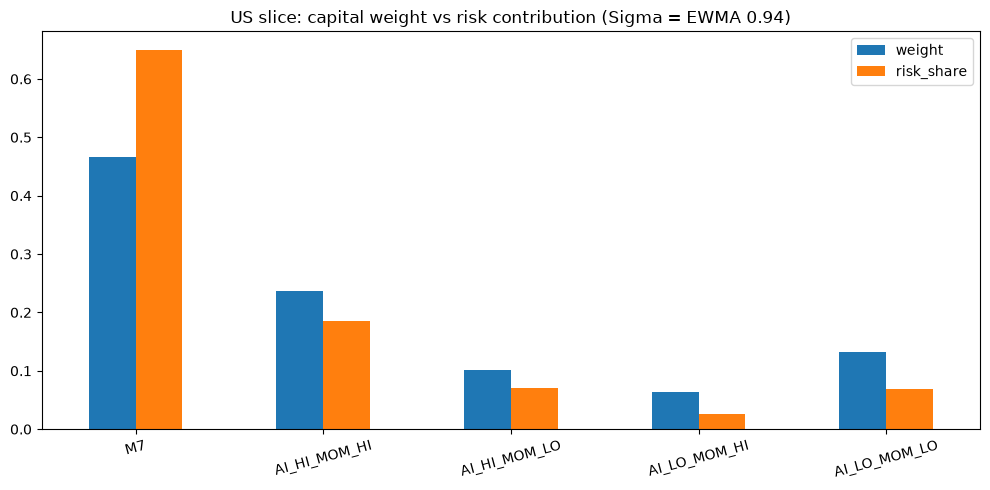

In [ ]:
from scipy.stats import norm

BASKETS = ["M7", "AI_HI_MOM_HI", "AI_HI_MOM_LO", "AI_LO_MOM_HI", "AI_LO_MOM_LO"]

weights_all = pd.to_numeric(
    equity_holdings.set_index("Ticker")["Weight (%)"],
    errors="coerce").dropna() #use the current iShares capital weights for each ticker across the full history for now

basket_assignment_by_quarter_end = {} #store the basket for every ticker at every formation date
for quarter_end, quarter_end_loadings in sorted(loadings_by_qe.items()): #repeat the same 2x2 median sort at every quarter-end
    quarter_end_position = members_returns.index.get_loc(quarter_end) #find this quarter-end in the daily return index
    if quarter_end_position < 252: #momentum needs 252 prices before the formation date
        continue

    momentum_at_quarter_end = tickers_data.iloc[quarter_end_position-21] / tickers_data.iloc[quarter_end_position-252] - 1 #calculate 12-1 momentum at this quarter-end
    sorting_table = quarter_end_loadings.drop(columns="momentum", errors="ignore").join(momentum_at_quarter_end.rename("momentum")) #join momentum to the AI loadings for this formation date
    sorting_table = sorting_table.drop(index=[ticker for ticker in M7_FULL if ticker in quarter_end_loadings.index], errors="ignore") #keep Mag-7 outside of the 2x2 sort
    sorting_table = sorting_table.dropna(subset=["ai_beta", "momentum"]) #only sort stocks that have both values

    high_ai_at_quarter_end = sorting_table["ai_beta"] >= sorting_table["ai_beta"].median() #high AI exposure means at or above the cross-sectional median
    high_momentum_at_quarter_end = sorting_table["momentum"] >= sorting_table["momentum"].median() #high momentum means at or above the cross-sectional median
    basket_labels = np.select(
        [high_ai_at_quarter_end & high_momentum_at_quarter_end,
         high_ai_at_quarter_end & ~high_momentum_at_quarter_end,
         ~high_ai_at_quarter_end & high_momentum_at_quarter_end,
         ~high_ai_at_quarter_end & ~high_momentum_at_quarter_end],
        BASKETS[1:],
        default="UNASSIGNED") #assign the four ex-Mag-7 baskets using the same labels defined above

    basket_assignment = pd.Series(basket_labels, index=sorting_table.index) #map each ex-Mag-7 ticker to its basket
    mag7_assignment = pd.Series("M7", index=[ticker for ticker in M7_FULL if ticker in members_returns.columns]) #put both Alphabet share classes and the rest of Mag-7 in their own basket
    basket_assignment_by_quarter_end[quarter_end] = pd.concat([basket_assignment, mag7_assignment]) #save the complete ticker-to-basket mapping for this quarter-end

quarter_end_sorted = sorted(basket_assignment_by_quarter_end) #run the formation dates in chronological order
quarterly_basket_returns = [] #store one dataframe of daily basket returns for each following quarter

for quarter_end_number, quarter_end in enumerate(quarter_end_sorted):
    following_quarter_end = quarter_end_sorted[quarter_end_number+1] if quarter_end_number+1 < len(quarter_end_sorted) else members_returns.index[-1] #use the next formation date or the final available date
    following_quarter_returns = members_returns.loc[(members_returns.index > quarter_end) & (members_returns.index <= following_quarter_end)] #the quarter-end assignment starts on the next trading day
    if following_quarter_returns.empty:
        continue

    quarter_basket_assignment = basket_assignment_by_quarter_end[quarter_end] #use this formation date's basket membership for the following quarter
    basket_returns_this_quarter = {} #store the daily return series for each basket in this quarter

    for basket_name in BASKETS:
        basket_tickers = [ticker for ticker in quarter_basket_assignment.index[quarter_basket_assignment == basket_name]
                          if ticker in following_quarter_returns.columns and ticker in weights_all.index] #only use tickers with both returns and an iShares weight
        basket_member_returns = following_quarter_returns[basket_tickers] #daily returns for the stocks in this basket
        basket_member_weights = weights_all[basket_tickers] #current iShares weights for the same stocks
        weighted_return_each_day = (basket_member_returns.fillna(0) * basket_member_weights).sum(axis=1) #a missing stock return contributes zero to the numerator
        available_weight_each_day = (basket_member_returns.notna() * basket_member_weights).sum(axis=1) #only count weights for stocks with a return that day
        basket_returns_this_quarter[basket_name] = weighted_return_each_day / available_weight_each_day #reweight the available basket members each day

    quarterly_basket_returns.append(pd.DataFrame(basket_returns_this_quarter)) #add this quarter's five basket return series

basket_returns_by_day = pd.concat(quarterly_basket_returns).sort_index() #combine every quarter into one daily history

mag7_validation = pd.concat([basket_returns_by_day["M7"], benchmark_returns["MAGS"]], axis=1).dropna() #compare the synthetic Mag-7 basket with the traded MAGS ETF
print(f"M7 vs MAGS daily corr ({mag7_validation.index[0].date()} →): {mag7_validation.corr().iloc[0,1]:.4f}") #MAGS is closer to equal-weighted, so explain any shortfall from a correlation near 0.99

latest_basket_assignment = basket_assignment_by_quarter_end[quarter_end_sorted[-1]] #use the most recent formation for current basket weights
basket_capital_weights = pd.Series({
    basket_name: weights_all[[ticker for ticker in latest_basket_assignment.index[latest_basket_assignment == basket_name]
                              if ticker in weights_all.index]].sum()
    for basket_name in BASKETS}) #sum the iShares capital weights inside each current basket
portfolio_weights = (basket_capital_weights / basket_capital_weights.sum()).reindex(BASKETS) #normalize the US slice so the five basket weights add to 1

complete_basket_returns = basket_returns_by_day.dropna() #use dates where all five baskets have a return for the covariance estimates
full_sample_covariance = complete_basket_returns.cov() #full 2019-to-present covariance with equal weight on each date
trailing_year_covariance = complete_basket_returns.tail(252).cov() #covariance over the latest 252 trading days

ewma_covariance_values = trailing_year_covariance.values.copy() #start the EWMA recursion with the trailing-year covariance
for daily_basket_returns in complete_basket_returns.values:
    ewma_covariance_values = 0.94 * ewma_covariance_values + 0.06 * np.outer(daily_basket_returns, daily_basket_returns) #RiskMetrics EWMA with an approximately 11-day half-life

ewma_covariance = pd.DataFrame(
    ewma_covariance_values,
    index=complete_basket_returns.columns,
    columns=complete_basket_returns.columns) #put the EWMA covariance back into a labelled dataframe

var_quantile_99 = norm.ppf(0.01) #one-percent normal quantile used for 99% VaR
expected_shortfall_coefficient_99 = norm.pdf(norm.ppf(0.01)) / 0.01 #normal expected-shortfall tail coefficient at 99%

def calculate_risk_decomposition(covariance_matrix, portfolio_weight_series):
    portfolio_weights_array = portfolio_weight_series.reindex(covariance_matrix.columns).values #put the weights in the same order as the covariance matrix
    covariance_times_weights = covariance_matrix.values @ portfolio_weights_array #calculate Sigma times the portfolio weights
    portfolio_daily_volatility = float(np.sqrt(portfolio_weights_array @ covariance_matrix.values @ portfolio_weights_array)) #daily volatility of the US slice
    marginal_risk_contribution = covariance_times_weights / portfolio_daily_volatility #change in portfolio volatility from increasing each basket weight
    component_risk = portfolio_weights_array * marginal_risk_contribution #Euler component risk, which adds back to total portfolio volatility

    risk_decomposition_table = pd.DataFrame({
        "weight": portfolio_weights_array,
        "ann_vol": np.sqrt(np.diag(covariance_matrix.values) * 252), #annualized standalone volatility for each basket
        "risk_share": component_risk / component_risk.sum(), #each basket's share of total portfolio volatility
        "dVaR_10D": var_quantile_99 * marginal_risk_contribution * np.sqrt(10), #99% ten-day VaR sensitivity to each basket weight
        "dES_10D": -expected_shortfall_coefficient_99 * marginal_risk_contribution * np.sqrt(10)}, #99% ten-day expected-shortfall sensitivity to each basket weight
        index=covariance_matrix.columns)

    return risk_decomposition_table, portfolio_daily_volatility

risk_decomposition_results = {} #store the decomposition table produced by each covariance estimate
covariance_estimates = [
    ("full-sample", full_sample_covariance),
    ("trailing 1y", trailing_year_covariance),
    ("EWMA 0.94", ewma_covariance)]

for estimator_name, covariance_matrix in covariance_estimates:
    risk_decomposition_table, portfolio_daily_volatility = calculate_risk_decomposition(covariance_matrix, portfolio_weights)
    risk_decomposition_results[estimator_name] = risk_decomposition_table

    mag7_risk_concentration = risk_decomposition_table.loc["M7", "risk_share"] / risk_decomposition_table.loc["M7", "weight"] #Mag-7 risk share relative to its capital weight
    ai_risk_share_gap = risk_decomposition_table.loc[["AI_HI_MOM_HI", "AI_HI_MOM_LO"], "risk_share"].sum() - risk_decomposition_table.loc[["AI_LO_MOM_HI", "AI_LO_MOM_LO"], "risk_share"].sum() #risk-share difference between high- and low-AI baskets
    momentum_risk_share_gap = risk_decomposition_table.loc[["AI_HI_MOM_HI", "AI_LO_MOM_HI"], "risk_share"].sum() - risk_decomposition_table.loc[["AI_HI_MOM_LO", "AI_LO_MOM_LO"], "risk_share"].sum() #risk-share difference between high- and low-momentum baskets

    print(f"\n--- Sigma = {estimator_name}   (US-slice ann vol ~ {portfolio_daily_volatility*np.sqrt(252):.1%}) ---")
    print(risk_decomposition_table.round(3))
    print(f"M7 risk-share/weight = {mag7_risk_concentration:.2f}x | AI-split gap {ai_risk_share_gap:+.1%} vs Mom-split gap {momentum_risk_share_gap:+.1%}")

risk_decomposition_results["EWMA 0.94"][["weight", "risk_share"]].plot.bar(
    figsize=(10,5),
    rot=15,
    title="US slice: capital weight vs risk contribution (Sigma = EWMA 0.94)") #compare the current capital weights with their EWMA risk contributions
plt.tight_layout()
